Step 1 — Load everything you saved in Stage 3

In [2]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

# Load the model and scaler you saved
model  = pickle.load(open('model/xgb_model.pkl', 'rb'))
scaler = pickle.load(open('model/scaler.pkl', 'rb'))

# Load the cleaned data
df = pd.read_csv('data/diabetes_cleaned.csv')

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df[features]
X_scaled = scaler.transform(X)

print("Data loaded successfully!")
print("Patients:", len(X))

Data loaded successfully!
Patients: 768


Step 2 — Create the SHAP explainer

In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

print("SHAP values shape:", shap_values.shape)
print("Each row = one patient, each column = one feature's contribution")
print("\nExample — SHAP values for patient 0:")
for feat, val in zip(features, shap_values[0]):
    direction = "↑ increases risk" if val > 0 else "↓ decreases risk"
    print(f"  {feat:30s} {val:+.4f}  {direction}")

SHAP values shape: (768, 8)
Each row = one patient, each column = one feature's contribution

Example — SHAP values for patient 0:
  Pregnancies                    -0.1499  ↓ decreases risk
  Glucose                        +0.5241  ↑ increases risk
  BloodPressure                  +0.0772  ↑ increases risk
  SkinThickness                  +0.1106  ↑ increases risk
  Insulin                        +0.2263  ↑ increases risk
  BMI                            +0.1712  ↑ increases risk
  DiabetesPedigreeFunction       +0.2220  ↑ increases risk
  Age                            +0.5867  ↑ increases risk


Step 3 — Summary plot (most important features overall)

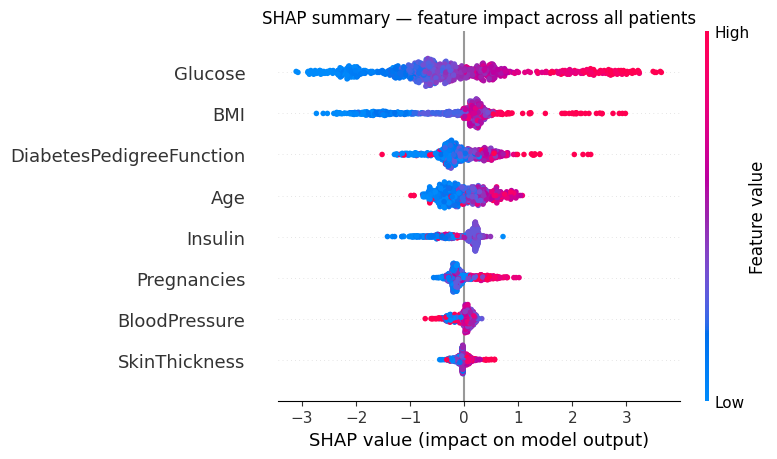

Chart saved!


In [4]:
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP summary — feature impact across all patients')
plt.tight_layout()
plt.savefig('charts/shap_summary.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

Step 4 — Bar plot (clean version for your README)

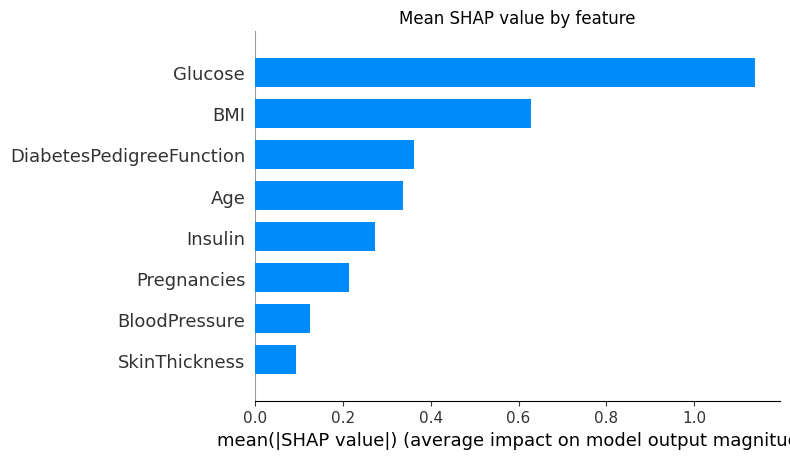

Chart saved!


In [5]:
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('Mean SHAP value by feature')
plt.tight_layout()
plt.savefig('charts/shap_bar.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

Step 5 — Waterfall plot for one patient

Patient 5 details:
Pregnancies                   5.000
Glucose                     116.000
BloodPressure                74.000
SkinThickness                29.000
Insulin                     125.000
BMI                          25.600
DiabetesPedigreeFunction      0.201
Age                          30.000
Name: 5, dtype: float64

Predicted diabetes risk: 3.5%


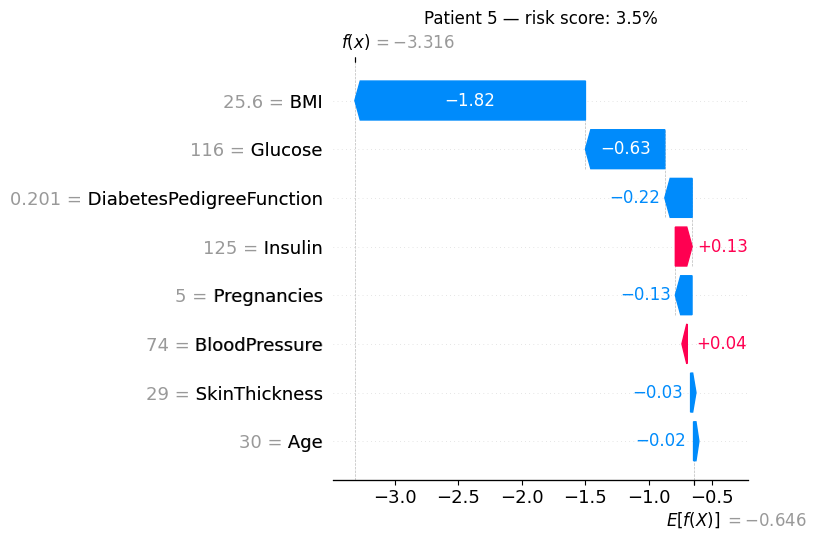

Chart saved!


In [6]:
# Let's explain patient index 5 — feel free to change this number
patient_index = 5

patient_data  = X.iloc[patient_index]
patient_shap  = shap_values[patient_index]
risk_score    = model.predict_proba(X_scaled[patient_index].reshape(1, -1))[0][1]

print(f"Patient {patient_index} details:")
print(patient_data)
print(f"\nPredicted diabetes risk: {risk_score:.1%}")

shap.waterfall_plot(
    shap.Explanation(
        values=patient_shap,
        base_values=explainer.expected_value,
        data=patient_data,
        feature_names=features
    ),
    show=False
)
plt.title(f'Patient {patient_index} — risk score: {risk_score:.1%}')
plt.tight_layout()
plt.savefig('charts/shap_waterfall.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

How to read the waterfall: It starts from the average prediction (the base value) and shows how each feature pushed the final score up (red) or down (blue). The final bar is your patient's actual risk score.

Step 6 — Dependence plot for Glucose

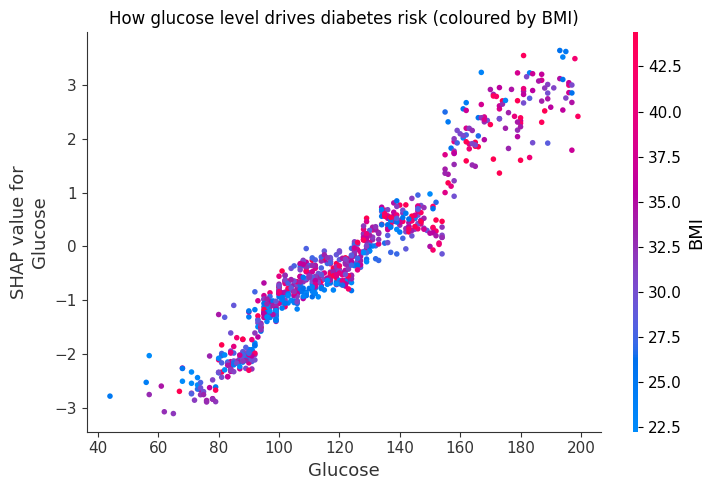

Chart saved!


In [7]:
shap.dependence_plot(
    'Glucose',
    shap_values,
    X,
    interaction_index='BMI',
    show=False
)
plt.title('How glucose level drives diabetes risk (coloured by BMI)')
plt.tight_layout()
plt.savefig('charts/shap_dependence_glucose.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

Step 7 — Save SHAP values for use in the dashboard

In [8]:
shap_df = pd.DataFrame(shap_values, columns=[f'shap_{f}' for f in features])
shap_df.to_csv('data/shap_values.csv', index=False)
print("SHAP values saved!")
print(shap_df.head())

SHAP values saved!
   shap_Pregnancies  shap_Glucose  shap_BloodPressure  shap_SkinThickness  \
0         -0.149927      0.524132            0.077214            0.110566   
1         -0.266340     -2.167494            0.098133           -0.103307   
2          0.676243      3.230357            0.178657           -0.036618   
3         -0.210859     -1.877806            0.012882           -0.119173   
4         -0.108638      0.393242            0.085832            0.142411   

   shap_Insulin  shap_BMI  shap_DiabetesPedigreeFunction  shap_Age  
0      0.226297  0.171206                       0.222022  0.586741  
1      0.112244 -1.613374                      -0.197140  0.036719  
2      0.075300 -1.171964                       0.285370  0.194241  
3     -0.248251 -0.100357                      -0.412432 -0.532036  
4      0.205902  0.824610                      -0.447276  0.175371  
